# Grilles alternées pour les ondes en eau peu profonde

Le but de ce TD est de calculer la dynamique d'ondes d'inertie gravité en eau peu profonde, et de montrer l'intrêt des grilles décalées (staggered grid) popularisées en dynamique des fluides géophysiques par Arakawa dans les années 70.

> Arakawa, A.; Lamb, V.R. (1977). "Computational design of the basic dynamical processes of the UCLA general circulation model". Methods in Computational Physics: Advances in Research and Applications

Commençons par importer les modules nécessaires : 


In [2]:
import numpy as np
import matplotlib.pyplot as plt


### Cas 1D sans rotation



On considère les équations des ondes en eau peu profonde (shallow water)
linéarisées autour d’un état de repos, sans rotation et en une dimension d’espace, sur un domaine périodique de longueur $L$ (assimilable à un cercle de latitude) :



\begin{align}
  \partial_t u + g\, \partial_x \eta & = 0  \\
  \partial_t \eta + H\, \partial_x u & = 0,
\end{align}

  - $u(x,t)$ est la vitesse horizontale,
  - $\eta(x,t)$ est l’élévation de la surface libre,
  - $H$ est la profondeur moyenne (constante),
  - $g$ est l’accélération de la pesanteur.

In [3]:
G = 9.81 # m/s^2
H = 4 # km, echelle verticale
L = 100 # km echelle horizontale
T = 1 # temps typique pour une onde de taille L

**Question 1** : Montrer que le système admet des solutions sous forme d’ondes planes. Déterminer et interpreter la relation de dispersion. Le système est-il dispersif ?


>**Réponse 1.** : 
> $$(u,\eta)= (u_0,\eta_0)e^{ikx-i\omega t} .$$
>$$\omega =\pm c k,\quad c=\sqrt{gH}$$
>
>Le système décrit deux ondes contra-propagatives. Les vitesses de phase $\omega/k$ et de groupe $\partial \omega/\partial k$ sont constantes et identiques, il s'agit donc d'une onde non dispersive.

**Question 2 :** On considère une grille de points de colocation
$x_j = j \Delta x$, $j=0,\dots,N-1$, avec $\Delta x = L/N$. Quelle est le plus petit nombre d’onde pouvant être représentée sur cette grille ? Quelle est le plus grand ?

>**Réponse 2 :**  Sur l'interval de Nyquist nous avons : $$ k_\text{min}=\frac{2\pi}{L},\quad k_\text{max}= \frac{\pi}{\Delta x} =\frac{N \pi }{L} .$$

**Question 3 :** On note $(u_j^n,\eta_j^n)$ les valeurs numériques aux points $x_j$ et au temps $t^n = n \Delta t$.  Écrire analytiquement et à l'aide d'une fonction python un schéma leapfrog centré d’ordre 2 en espace et en temps pour cette grille.

> **Réponse 3:** 
\begin{align}
              \frac{u^{n+1}_j-u^{n-1}_j}{2\Delta t}       & = -g\frac{\eta^{n}_{j+1}-\eta^{n}_{j-1}}{2 \Delta x} \\
              \frac{\eta^{n+1}_j-\eta^{n-1}_j}{2\Delta t} & = -H\frac{u^{n}_{j+1}-u^{n}_{j-1}}{2 \Delta x}
\end{align}



In [4]:
dt, dx = 0.01, 0.1
number_of_time_steps = int(20 * T/dt) # on fait tourner la simulation pendant 10 périodes d'oscillation 
number_of_space_steps = int(L/dx)

# Exemple des arrays pour stocker les résultats
u = np.zeros((number_of_time_steps, number_of_space_steps))
eta = np.zeros((number_of_time_steps, number_of_space_steps))

In [5]:
def leapfrog_step(u, eta, dt, dx, step):

    """ Intégration temporelle en utilisant le schéma de Leapfrog pour les équations de Shallow Water.
    Parameters:
    u : 2D array
        Zonal velocity component for all time steps. (shape: (nt, nx))
    eta : 2D array
        surface elevation component for all time steps . (shape: (nt, nx))
    dt : float
        Time step size.
    dx : float
        Grid spacing in the x-direction.
    step : int
        Current time step index.
    """
    if step < 1:
        raise ValueError("Leapfrog scheme requires at least two previous time steps.")
        
    # Compute the derivatives
    du_dx = (np.roll(u[step], -1) - np.roll(u[step], 1)) / ( 2 * dx) # Periodic boundary conditions
    deta_dx = (np.roll(eta[step], -1) - np.roll(eta[step], 1)) / ( 2 * dx) # Periodic boundary conditions

    # Update the velocity fields using the leapfrog scheme
    u[step + 1] = u[step - 1] - 2 * G * dt * deta_dx
    eta[step + 1] = eta[step - 1] - 2 * H * dt * du_dx

**Question 4 :** Expliquez quel problème apparaît lors de l'initialisation de la simulation et proposez une solution simple pour le résoudre. Quel est le problème avec ce shéma d'intégration.

>**Réponse 4 :** le schéma leapfrog utilisé ci-dessus est un schéma à deux pas de temps (multi-step). Leapfrog nécessite les valeurs des champs à $n$ et $n-1$ pour calculer n+1. Au temps initial, on ne dispose que de la condition initiale à $t=0$. Il manque une valeur à $t=-\Delta t$. Si on utilise directement leapfrog et une condition arbitraire en $t=-\Delta t$, on peut géné rer un mode numérique parasite.  
>
>Solution simple : fournir la valeur du champ à $t= \Delta t$ à l’aide d’un schéma $mono-step$ comme Euler explicite (mais on perd l'ordre 2 du schéma) ou  Runge-Kutta d’ordre 2, qui permet de conserver une erreur d'ordre 2. Attention, le mode numérique peut tout de même emerger par accumulation des erreurs d'arrondi dans ces cas. Par ailleurs, si l'on ajoute les termes nonlinéaires du modèle, cela induit un couplage entre le mode physique et le mode numérique. Dans ces cas, il est nécessaire d'ajouter un terme de filtrage en temps qui lisse les fluctuations associées au mode numérique (filtre Robert-Asselin). 

**Question 5 :** Pour pallier à ce problème d'initialisation nous proposons les fonctions d'initialisations suivantes. Quelle est la différence entre les deux, pourquoi l'une est à privilégier ? Un calcul complet de l'erreur commise est attendu pour les deux méthodes

In [6]:
def euler_init(u, eta, dt, dx):

    """Initialize the velocity fields using a Runge-Kutta method for the shallow water equations.
    Parameters:
    u : 2D array
        Zonal velocity component for all time steps. (shape: (nt, nx))
    eta : 2D array
        Meridional velocity component for all time steps . (shape: (nt, nx))
    dt : float
        Time step size.
    dx : float
        Grid spacing in the x-direction.
    """
    # Compute the derivatives
    du_dx = (np.roll(u[0], -1) - np.roll(u[0], 1)) / ( 2 * dx) # Periodic boundary conditions
    deta_dx = (np.roll(eta[0], -1) - np.roll(eta[0], 1)) / ( 2 * dx) # Periodic boundary conditions

    # Update the velocity fields using a simple forward Euler step for initialization
    u[1] = u[0] - G * dt * deta_dx
    eta[1] = eta[0] - H * dt * du_dx

In [7]:
def Runge_Kutta_init(u, eta, dt, dx):

    """Initialize the velocity fields using a Runge-Kutta method (mid point Euler) for the shallow water equations.
    Parameters:
    u : 2D array
        Zonal velocity component for all time steps. (shape: (nt, nx))
    eta : 2D array
        interface elevation for all time steps . (shape: (nt, nx))
    dt : float
        Time step size.
    dx : float
        Grid spacing in the x-direction.
    """
    # Compute the derivatives at the initial time step
    du_dx = (np.roll(u[0], -1) - np.roll(u[0], 1)) / ( 2 * dx) # Periodic boundary conditions
    deta_dx = (np.roll(eta[0], -1) - np.roll(eta[0], 1)) / ( 2 * dx) # Periodic boundary conditions

    # Compute the intermediate values for the Runge-Kutta method
    u_half = u[0] - 0.5 * G * dt * deta_dx
    eta_half = eta[0] - 0.5 * H * dt * du_dx

    # Compute the derivatives at the intermediate time step
    du_dx_half = (np.roll(u_half, -1) - np.roll(u_half, 1)) / ( 2 * dx) # Periodic boundary conditions
    deta_dx_half = (np.roll(eta_half, -1) - np.roll(eta_half, 1)) / ( 2 * dx) # Periodic boundary conditions

    # Update the velocity fields using the Runge-Kutta method
    u[1] = u[0] - G * dt * deta_dx_half
    eta[1] = eta[0] - H * dt * du_dx_half

> **Réponse 5 :** La méthode la plus adaptée à notre problème est la méthode de Runge-Kutta d'ordre 2. 
> - En effet si l'on considère la méthode Forward d'euler nous avons directement pour une fonction $\psi$ solution du problème  
\begin{align}
    \delta = \psi(t + \Delta t) - \psi(t) - \Delta t \partial_t \psi(t) = O(\Delta t^2)
\end{align}
>La méthode est donc d'ordre un puisque l'erreur de troncature $\delta$ est d'ordre $\Delta t^2$
>
>- Dans le cas de la méthode de Runge-Kutta d'ordre 2, nous avons : 
\begin{align}
    \delta(\Delta t) &= \psi(t + \Delta t) - \psi(t) - \Delta t \mathcal{F}(t +  \tfrac{\Delta t}{2}, \psi(t) + \tfrac{\Delta t}{2} \mathcal{F}(t,  \psi)) \\
                     &= \partial_t \psi \Delta t +  \tfrac{\Delta t^2}{2} \partial_t^2 + O(\Delta t^3) - \Delta t \partial_t \psi - \tfrac{\Delta t^2}{2} \partial_t^2 \psi \\
                     & = O(\Delta t^3)
\end{align}
On trouve ainsi que la méthode RK2 est bien d'ordre 2 puisque l'erreur de troncature $\delta$ est d'ordre de grandeur $\Delta t^3$. 

Remarque : il existe plusieurs schéma possibles RK2. On a vu en cours le schéma de RK2 "Heun". On a implémenté ici le schéma RK2 "Mid Point Euler". Les deux schéma sont d'ordre 2 mais la constante diffère. Les propriétés de stabilité des deux schéma sont un peu différentes.


**Question 6 :** On donne la fonction permettant de calculer les conditions initiales correspondant à un bump gaussien centré: 

\begin{equation}
\eta(t=0,x) = u(t=0,x) = \exp(-(x - \tfrac{L}{2})^2 / (2\sigma^2)) \quad \text{with} \quad \sigma = \tfrac{L}{10}
\end{equation}
Nous donnons également la solution analytique pour cette CI. Intégrer la solution pour le pas de temps fixé

In [8]:
def init_cond(u,eta):
    """Conditions initiales : bump gaussien au milieu du domaine
    Parameters:
    u : 2D array
        Composante zonale de la vitesse pour tous les pas de temps. (shape: (nt, nx))
    eta : 2D array
        élévation d'interface  pour tous les pas de temps. (shape: (nt, nx))
    """
    # Créer une perturbation gaussienne au milieu du domaine
    x = np.linspace(0, L, number_of_space_steps)
    gaussian_perturbation = np.exp(-((x - L/2)**2) / (2 * (L/10)**2))

    u[0] = gaussian_perturbation
    eta[0] = gaussian_perturbation

def analytic_solution(x, t):
    
    c = np.sqrt(G * H) 
    sigma = L / 10.0
    x0 = L / 2.0
    xm = (x - c*t) % L
    xp = (x + c*t) % L
    f_m = np.exp(-((xm - x0)**2) / (2.0 * sigma**2))   # f(x-ct)
    f_p = np.exp(-((xp - x0)**2) / (2.0 * sigma**2))   # f(x+ct)
    a = 1.0 + G / c
    b = 1.0 - G / c
    u_analytic   = 0.5 * (a * f_m + b * f_p)
    eta_analytic = (c / (2.0 * G)) * (a * f_m - b * f_p)

    return u_analytic, eta_analytic


In [9]:
def solve_shallow_water(dt, dx, initialization_method='Runge-Kutta'):

    """Solve the shallow water equations using a leapfrog time-stepping scheme.
    Parameters:
    u : 2D array
        Zonal velocity component for all time steps. (shape: (nt, nx))
    eta : 2D array
        interface elevation for all time steps . (shape: (nt, nx))
    dt : float
        Time step size.
    dx : float
        Grid spacing in the x-direction.
    number_of_time_steps : int
        Total number of time steps to simulate.
    """
    
    number_of_space_steps, number_of_time_steps = int(L/dx), int(20 * T/dt)
    u = np.zeros((number_of_time_steps, number_of_space_steps))
    eta = np.zeros((number_of_time_steps, number_of_space_steps))
    init_cond(u,eta)

    init_funcs = {'Runge-Kutta': Runge_Kutta_init, 'Euler': euler_init}
    init_funcs[initialization_method](u, eta, dt, dx)
    
    for step in range(1, number_of_time_steps - 1):
        leapfrog_step(u, eta, dt, dx, step)
    return u, eta

x = np.linspace(0, L, number_of_space_steps)
t = np.linspace(0, 20 * T, number_of_time_steps)
x,t = np.meshgrid(x, t)
u_analytic, eta_analytic = analytic_solution(x, t)

In [10]:
u, eta = solve_shallow_water(dt, dx, initialization_method='Runge-Kutta')

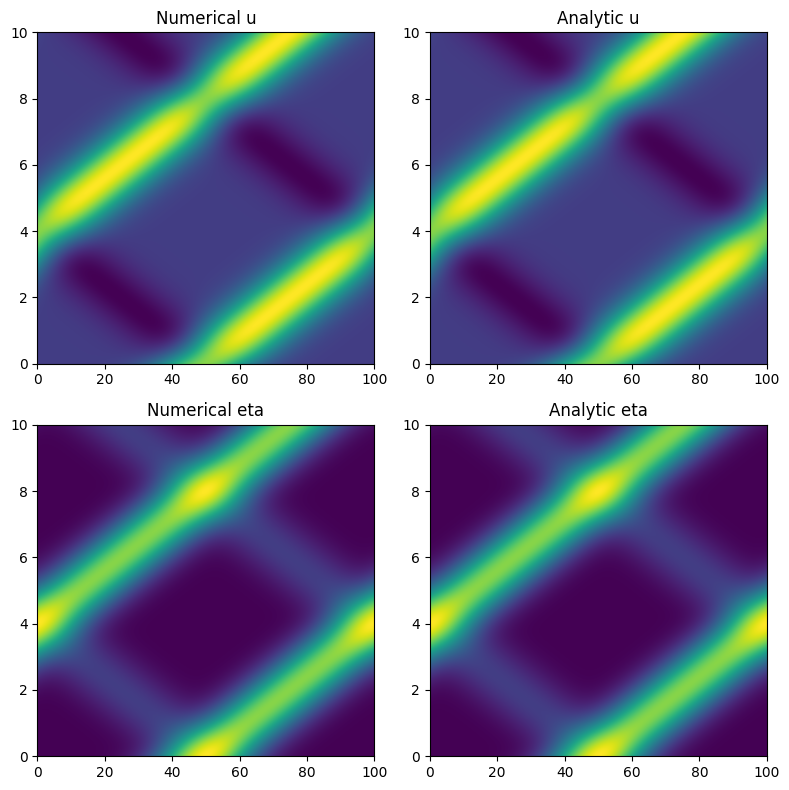

In [11]:
fig, ax = plt.subplots(2,2, figsize=(8, 8))
for i, (field, analytic_field) in enumerate(zip([u, eta], [u_analytic, eta_analytic])):
    ax[i,0].imshow(field, aspect='auto', origin='lower', extent=[0, L, 0, 10*T])
    ax[i,0].set_title(f"Numerical {['u', 'eta'][i]}")
    ax[i,1].imshow(analytic_field, aspect='auto', origin='lower', extent=[0, L, 0, 10*T])
    ax[i,1].set_title(f"Analytic {['u', 'eta'][i]}")
plt.tight_layout()

**Question 7 :** On propose d'effectuer une analyse de Von Neumann en supposant des solutions de la forme
$$ u_j^n = \hat u\, e^{i(k j \Delta x - \omega n \Delta t)}, \quad \eta_j^n = \hat \eta\, e^{i(k j \Delta x - \omega n \Delta t)}.$$
- (a) Pourquoi peut-on supposer $k$ réel ? $\omega$ est-il nécessairement réel ?
- (b)  Montrer que la relation de dispersion discrète s’écrit
$$ \sin(\omega \Delta t) = \pm \frac{c \Delta t}{\Delta x} \, \sin(k \Delta x),$$
où $c = \sqrt{gH}$ est la célérité.

>**Réponse 7 :**
>k est réel car on se restreint aux modes de Fourier. L'idée est que l'on peut projeter tout champ spatial sur une base de modes de Fourier. On considère un seul mode, et on anticipe que ce mode est un mode propre de l'opérateur spatial qui et invariant par translation. 
> Par ailleurs $k= m 2\pi /L $ avec $m=1..N$ est discret car le domaine est périodique. 
>En revanche, $\omega$ est complexe (puisque nous ne sommes pas périodique en temps). L'Ansatz injecté dans le schéma numérique donne : 
>\begin{align}
          \frac{2 i \sin (\omega \Delta t)}{2\Delta t} \hat{u}     & = -g\frac{2 i \sin(k\Delta x)}{2 \Delta x} \hat{\eta} \\
          \frac{2 i \sin (\omega \Delta t)}{2\Delta t}  \hat{\eta} & = -H\frac{2 i \sin(k\Delta x)}{2 \Delta x}  \hat{u},
\end{align} 
ce qui donne $$ \left(\sin(\omega \Delta t)\right)^2 = \left( \frac{c \Delta t}{\Delta x} \, \sin(k \Delta x)\right)^2,$$
avec $c = \sqrt{gH}$ est la célérité.


**Question 8:** Supposons pour le moment $w \in \mathbb{R}$ . Sous quelle condition sur le pas de temps cette hypothèse reste-elle valide ? En déduire une condition nécessaire de stabilité du schéma (condition CFL). Quel est la forme du mode dominant lorsque la solution explose . Illustrer ce phénomène à l'aide d'un choix judicieusement mal choisi des paramètres de discrétisation $\Delta t $ et $\Delta x$ : 

>**Réponse 8 :** 
>$\omega$ réel $\implies$ $|\sin(\omega \Delta t)| <1$. Le pire cas est atteint pour $k=k_{max}=\pi/2\Delta x$. Ainsi la condition  $\omega$ réel  est satisfaite pour 
> \begin{align} \Delta t < \frac{\Delta x}{c} .\end{align} 
>Par ailleurs, $\omega$ est soit purement réel, soit purement imaginaire avec une partie imaginaire positive, car  $\sin(\omega \Delta t )=\pm c\Delta t/\Delta x \sin(k\Delta x) $ est toujours réel. Ainsi la condition précédente sur $\Delta t$ donne une condition de stabilité CFL. le mode le plus instable est l'onde en dent de scie de taille $2\Delta x$.

In [12]:
dt, dx = 0.02, 0.1 # nous avons c ~ 10 
number_of_time_steps = int(20 * T/dt)
number_of_space_steps = int(L/dx)
x = np.linspace(0, L, number_of_space_steps)

In [13]:
u, eta = solve_shallow_water(dt, dx, initialization_method='Runge-Kutta')

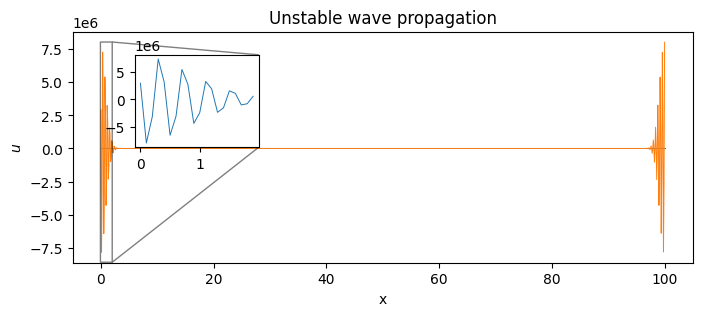

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
for i in range(0, number_of_time_steps //10, 50):
    ax.plot(x, u[i], label='Numerical u', lw = .7)
ax.set_xlabel('x')
ax.set_ylabel('$u$')
ax.set_title('Unstable wave propagation')
inset = ax.inset_axes([0.1, 0.5, 0.2, 0.4])
inset.plot(x[:20], u[number_of_time_steps //10- 50][:20], label='Initial condition', lw = .7)
ax.indicate_inset_zoom(inset, edgecolor="black")



**Question 9 :** On considère maintenant une grille décalée ("type C") :
        $\eta$ est définie aux centres de maille $x_j$ et $u$ aux interfaces $x_{j+1/2}$.
        On note $u_{j+1/2}^n$ et $\eta_j^n$ les valeurs des champs sur cette grille.
        Écrire le schéma leapfrog centré correspondant et la fonction python associée.

```text
      xj+1/2  xj xj+1/2 
    |    |    |    |    
----o----o----o----o----o---->
    |    |    |    |    |
    η    u     η    u    η
```


>**Réponse 9 :** Nous avons en appliquant simplement leap-frog : 
>\begin{align}
              \frac{u^{n+1}_{j+\frac{1}{2}}-u^{n-1}_{j+\frac{1}{2}}}{2\Delta t} & = -g\frac{\eta^{n}_{j+1}-\eta^{n}_{j
              }}{ \Delta x}                \\
              \frac{\eta^{n+1}_j-\eta^{n-1}_j}{2\Delta t}                       & = -H\frac{u^{n}_{j+\frac{1}{2}}-u^{n}_{j-\frac{1}{2}}}{\Delta x}
            \end{align}

In [15]:
# Exemple des arrays pour stocker les résultats
u = np.zeros((number_of_time_steps, number_of_space_steps)) # u[i,j] = u[i]_{j+1/2}
eta = np.zeros((number_of_time_steps, number_of_space_steps)) # eta[i,j] = eta[i]_{j}

In [16]:
def leapfrog_step_staggered(u, eta, dt, dx, step):

    """ Intégration temporelle en utilisant le schéma de Leapfrog pour les équations de Shallow Water avec une grille décalée.
    Parameters:
    u : 2D array
        Zonal velocity component for all time steps at the interfaces grid points. (shape: (nt, nx))
    eta : 2D array
        internace elecation component for all time steps at the staggered grid points. (shape: (nt, nx))
    dt : float
        Time step size.
    dx : float
        Grid spacing in the x-direction.
    step : int
        Current time step index.
    """
    if step < 1:
        raise ValueError("Leapfrog scheme requires at least two previous time steps.")
        
    # Compute the derivatives
    du_dx_center = (u[step] - np.roll(u[step], 1)) / dx # Periodic boundary conditions
    deta_dx_interface = (np.roll(eta[step], -1) - eta[step]) / dx # Periodic boundary conditions

    # Update the velocity fields using the leapfrog scheme
    u[step + 1] = u[step - 1] - 2 * G * dt * deta_dx_interface
    eta[step + 1] = eta[step - 1] - 2 * H * dt * du_dx_center

**Question 10 :** Comparer l'erreur de troncature spatiale (ordre 2 en $\Delta x$) de ce schéma à celle du précédent. Montrer que les deux schémas sont d'ordre 2 mais que leurs constantes d'erreur diffèrent. Quel pas de grille alternée $\Delta x_a$ permet d'obtenir la même précision que pour la grille non alternée de pas $\Delta x$ ?

> **Réponse 10 :** Estimons l'erreur de troncature sur la grille décalée pour l'estimation de la dérivée $\partial_x \eta $ en $x=x_{j+\frac{1}{2}}$. 
>Un développement de Taylor donne
>$$\frac{\eta_{j+1}-\eta_j}{\Delta x}= \frac{\partial \eta}{\partial x} +\frac{\Delta x^2}{24}\frac{\partial^3 \eta}{\partial x^3}  +O\left(\Delta x^4\right) $$
>Dans le cas de la grille non décalée, on estime la dérivée au point $x_j$ de la même manière :
>$$\frac{\eta_{j+1}-\eta_{j-1}}{2 \Delta x}= \frac{\partial \eta}{\partial x} +\frac{\Delta x^2}{6}\frac{\partial^3 \eta}{\partial x^3}  +O \left(\Delta x^4\right) $$
>Le rapport des erreur d'ordre deux est d'un quart. Le choix d'un pas de grille $\Delta x_a= 2\Delta x$ permet d'obtenir la même précision avec la grille alternée qu'avec la grille non alternée.
          

**Question 11 :** Reproduire l’analyse de Von Neumann pour ce schéma et donner la condition CFL. En posant : 
$$
    u_{j+\frac12}^n = \hat u\, e^{i(k(j+\frac12)\Delta x - \omega n\Delta t)},
    \qquad
    \eta_j^n = \hat \eta\, e^{i(k j\Delta x - \omega n\Delta t)}.
$$


**Réponse 11 :** Après substitution dans le schéma :
$$
    \frac{2 i \sin(\omega \Delta t)}{2\Delta t}\hat u
    =
    - g \frac{2 i \sin(k\Delta x/2)}{\Delta x}\hat \eta,
$$
$$
    \frac{2 i \sin(\omega \Delta t)}{2\Delta t}\hat \eta
    =
    - H \frac{2 i \sin(k\Delta x/2)}{\Delta x}\hat u.
$$

On obtient

$$
    \sin(\omega \Delta t)
    =
    \pm \frac{2 c \Delta t}{\Delta x}
    \sin\!\left(\frac{k\Delta x}{2}\right),
    \qquad c=\sqrt{gH}.
$$

La stabilité impose
$$
    \left|\frac{2 c \Delta t}{\Delta x}\right|\le 1,
    \quad
    \Rightarrow
    \quad
    \Delta t \le \frac{\Delta x}{2c}.
$$

**Question 12 :**  La CFL est-elle plus restrictive sur la grille décalée si l'on choisit $\Delta x$ de sorte à ce que la précision des deux schémas d'ordre deux soient les mêmes ?

**Réponse 12 :** 
>Pour un même $\Delta x$ :
>$$
    \Delta t \le \frac{\Delta x}{2c}
    \quad \text{(grille décalée)},
    \qquad
    \Delta t \le \frac{\Delta x}{c}
    \quad \text{(grille non décalée)}.$$
>L’erreur spatiale étant quatre fois plus petite sur la grille décalée, une précision équivalente est obtenue avec $\Delta x_a = 2\Delta x$. La CFL devient alors
> $$
    \Delta t \le \frac{\Delta x_a}{2c}
    =
    \frac{2\Delta x}{2c}
    =
    \frac{\Delta x}{c}.$$
>À précision égale, le pas de temps maximal est donc identique.

**Question 13 :** Comparer qualitativement les relations de dispersion des deux schémas et du cas analytique dans la limite $\omega \Delta t\rightarrow 0$. Discuter du comportement de la solution près de l’échelle de maille et des effets dispersifs à grande longueur d'onde.

>**Réponse 13 :** 
>Si $\omega \Delta t \ll 1$, alors $\sin(\omega \Delta t) \approx \omega \Delta t$.
>Grille non décalée :
>$$
>    \omega \approx \pm c \frac{\sin(k\Delta x)}{\Delta x}.
>$$
>Grille décalée :
>$$
>    \omega \approx \pm c \frac{2\sin(k\Delta x/2)}{\Delta x}.
>$$
>
>Pour $k\Delta x \ll 1$ :
>$$
>    \omega \approx \pm ck,
>$$
>dans les deux cas : les grandes longueurs d’onde sont bien reproduites.
>
>Pour $k\Delta x \approx \pi$ :
>la grille non décalée donne
>$
>\sin(k\Delta x)\to 0
>$,
>d’où une vitesse de phase fortement réduite. La dispersion numérique est importante près de la fréquence spatiale de Nyquist.
>
>Il est aussi instructif de regarder le comportement de la vitesse de groupe
>
>Pour la grille non décalée,
>$$
>    c_g = \frac{d\omega}{dk} = c \cos(k\Delta x).
>$$
>La vitesse de groupe devient négative lorsque $k\Delta x$ est proche de $\pi$ : l’énergie se propage alors dans le sens opposé au cas analytique. Il s’agit d’un artefact numérique sévère.
>
>Pour la grille décalée, $c_g = c \cos(k\Delta x/2)$. Lorsque $k\Delta x \to \pi$,
>$c_g \to 0$ mais ne devient pas négative.
>La dispersion numérique reste présente,
>mais le comportement est moins pathologique.

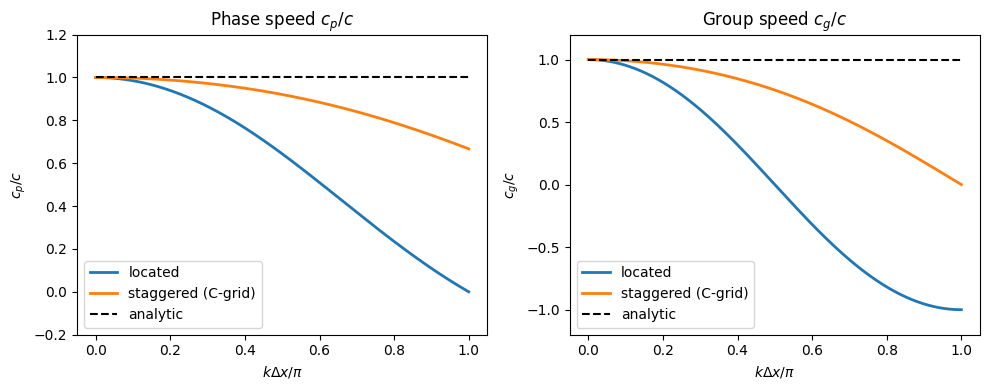

In [17]:

c = np.sqrt(G * H)
dx = 0.1
dt = 0.004  
C  = c * dt / dx

k = np.linspace(1e-12, np.pi/dx, 2000)  
kdx = k * dx

arg_  = C * np.sin(kdx)
arg_stag = 2*C * np.sin(0.5*kdx)

omega_ana  = c * k
omega_  = np.arcsin(arg_) / dt
omega_stag = np.arcsin(arg_stag) / dt

# Vitesses de phase
cp_ana  = omega_ana / k
cp_  = omega_ / k
cp_stag = omega_stag / k

# Vitesses de groupe
cg_ana  = np.gradient(omega_ana, k)
cg_  = np.gradient(omega_, k)
cg_stag = np.gradient(omega_stag, k)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax[0].plot(kdx/np.pi, cp_/c,  label="located", lw=2)
ax[0].plot(kdx/np.pi, cp_stag/c, label="staggered (C-grid)", lw=2)
ax[0].hlines(1.0, 0, 1, colors="k", linestyles="--", label="analytic")
ax[0].set_title("Phase speed $c_p/c$")
ax[0].set_ylabel("$c_p/c$")
ax[0].set_xlabel("$k\\Delta x / \\pi$")
ax[0].set_ylim(-0.2, 1.2)
ax[0].legend()

ax[1].plot(kdx/np.pi, cg_/c,  label="located", lw=2)
ax[1].plot(kdx/np.pi, cg_stag/c, label="staggered (C-grid)", lw=2)
ax[1].hlines(1.0, 0, 1, colors="k", linestyles="--", label="analytic")
ax[1].set_title("Group speed $c_g/c$")
ax[1].set_ylabel("$c_g/c$")
ax[1].set_xlabel("$k\\Delta x / \\pi$")
ax[1].set_ylim(-1.2, 1.2)
ax[1].legend()

plt.tight_layout()
plt.show()

**Question 14 :** Nous donnons la fonction RK2 pour initialiser note shéma numérique, une fonction permettant de créer un paquet d'onde localisé et un solveur en utilisant les fonctions précédemment définies. Visualisez les effet de dispersion associés aux méthodes présentées, en définissant correctement la variable $k_0$ (qui controle le nombre d'onde du paquet d'onde). 

- vous commenterez tout particulièrement la valeur $k_0$ = 0.5 et son comportement

In [18]:
def Runge_Kutta_init_staggered(u, eta, dt, dx):
    def rhs(u1, e1):
        deta_dx_u = (np.roll(e1, -1) - e1) / dx
        du_dx_e   = (u1 - np.roll(u1, 1)) / dx
        return (-G * deta_dx_u, -H * du_dx_e)

    k1u, k1e = rhs(u[0], eta[0])
    u_half   = u[0]   + 0.5*dt*k1u
    e_half   = eta[0] + 0.5*dt*k1e
    k2u, k2e = rhs(u_half, e_half)
    u[1]   = u[0]   + dt*k2u
    eta[1] = eta[0] + dt*k2e

In [19]:
def wave_packet(x, t, k0, sigma):
    # create a shallow water wave packet with wave number k0 and enveloppe size sigma propavating at celerity sqrt{g H}
    # will be used to initialize wavepacket at t=0 and compare numerical evolution with analytical one defined here. 
    c = np.sqrt(G * H)
    return np.exp(-((x - c*t) - L/2)**2 / (2*sigma**2)) * np.cos(k0 * (x - c*t))

In [20]:
import numpy as np
import matplotlib.pyplot as plt

c = np.sqrt(G * H) # shallow water celerity   
k0_factor = 0.6 #control wavenumber of wavepacket
sigma = 4 #control envelope of wavepacket

def run_packet(dx=0.2, dt=0.002, t_end=T):
    # grille décallée
    nx = int(L/dx)
    x_eta = np.arange(nx) * dx
    x_u   = (np.arange(nx) + 0.5) * dx

    # high-mode near Nyquist
    k0 = k0_factor * (np.pi/dx)
    eta0 = wave_packet(x_eta, 0, k0, sigma)
    u0 = (c/H) * eta0

# initialize wavepacket
    eta_bis = wave_packet(x_u, 0, k0, sigma)
    u0_stag   = (c/H)* eta_bis

    nt = int(t_end/dt) + 1
    t = np.arange(nt) * dt

    u  = np.zeros((nt, nx))
    eta  = np.zeros((nt, nx))
    
    u_stag = np.zeros((nt, nx))
    eta_stag = np.zeros((nt, nx))

    u[0] = u0
    eta[0] = eta0
    Runge_Kutta_init(u, eta, dt, dx)

    u_stag[0] = u0_stag
    eta_stag[0] = eta0
    Runge_Kutta_init_staggered(u_stag, eta_stag, dt, dx)

    for n in range(1, nt-1):
        leapfrog_step(u, eta, dt, dx, n)
        leapfrog_step_staggered(u_stag, eta_stag, dt, dx, n)

    return eta, eta_stag, u, u_stag, x_eta, t

dx = 0.01
dt = 0.0001 # satisfies both CFLs
eta, eta_stag, u, u_stag, x_eta, t = run_packet(dx=dx, dt=dt, t_end=T)

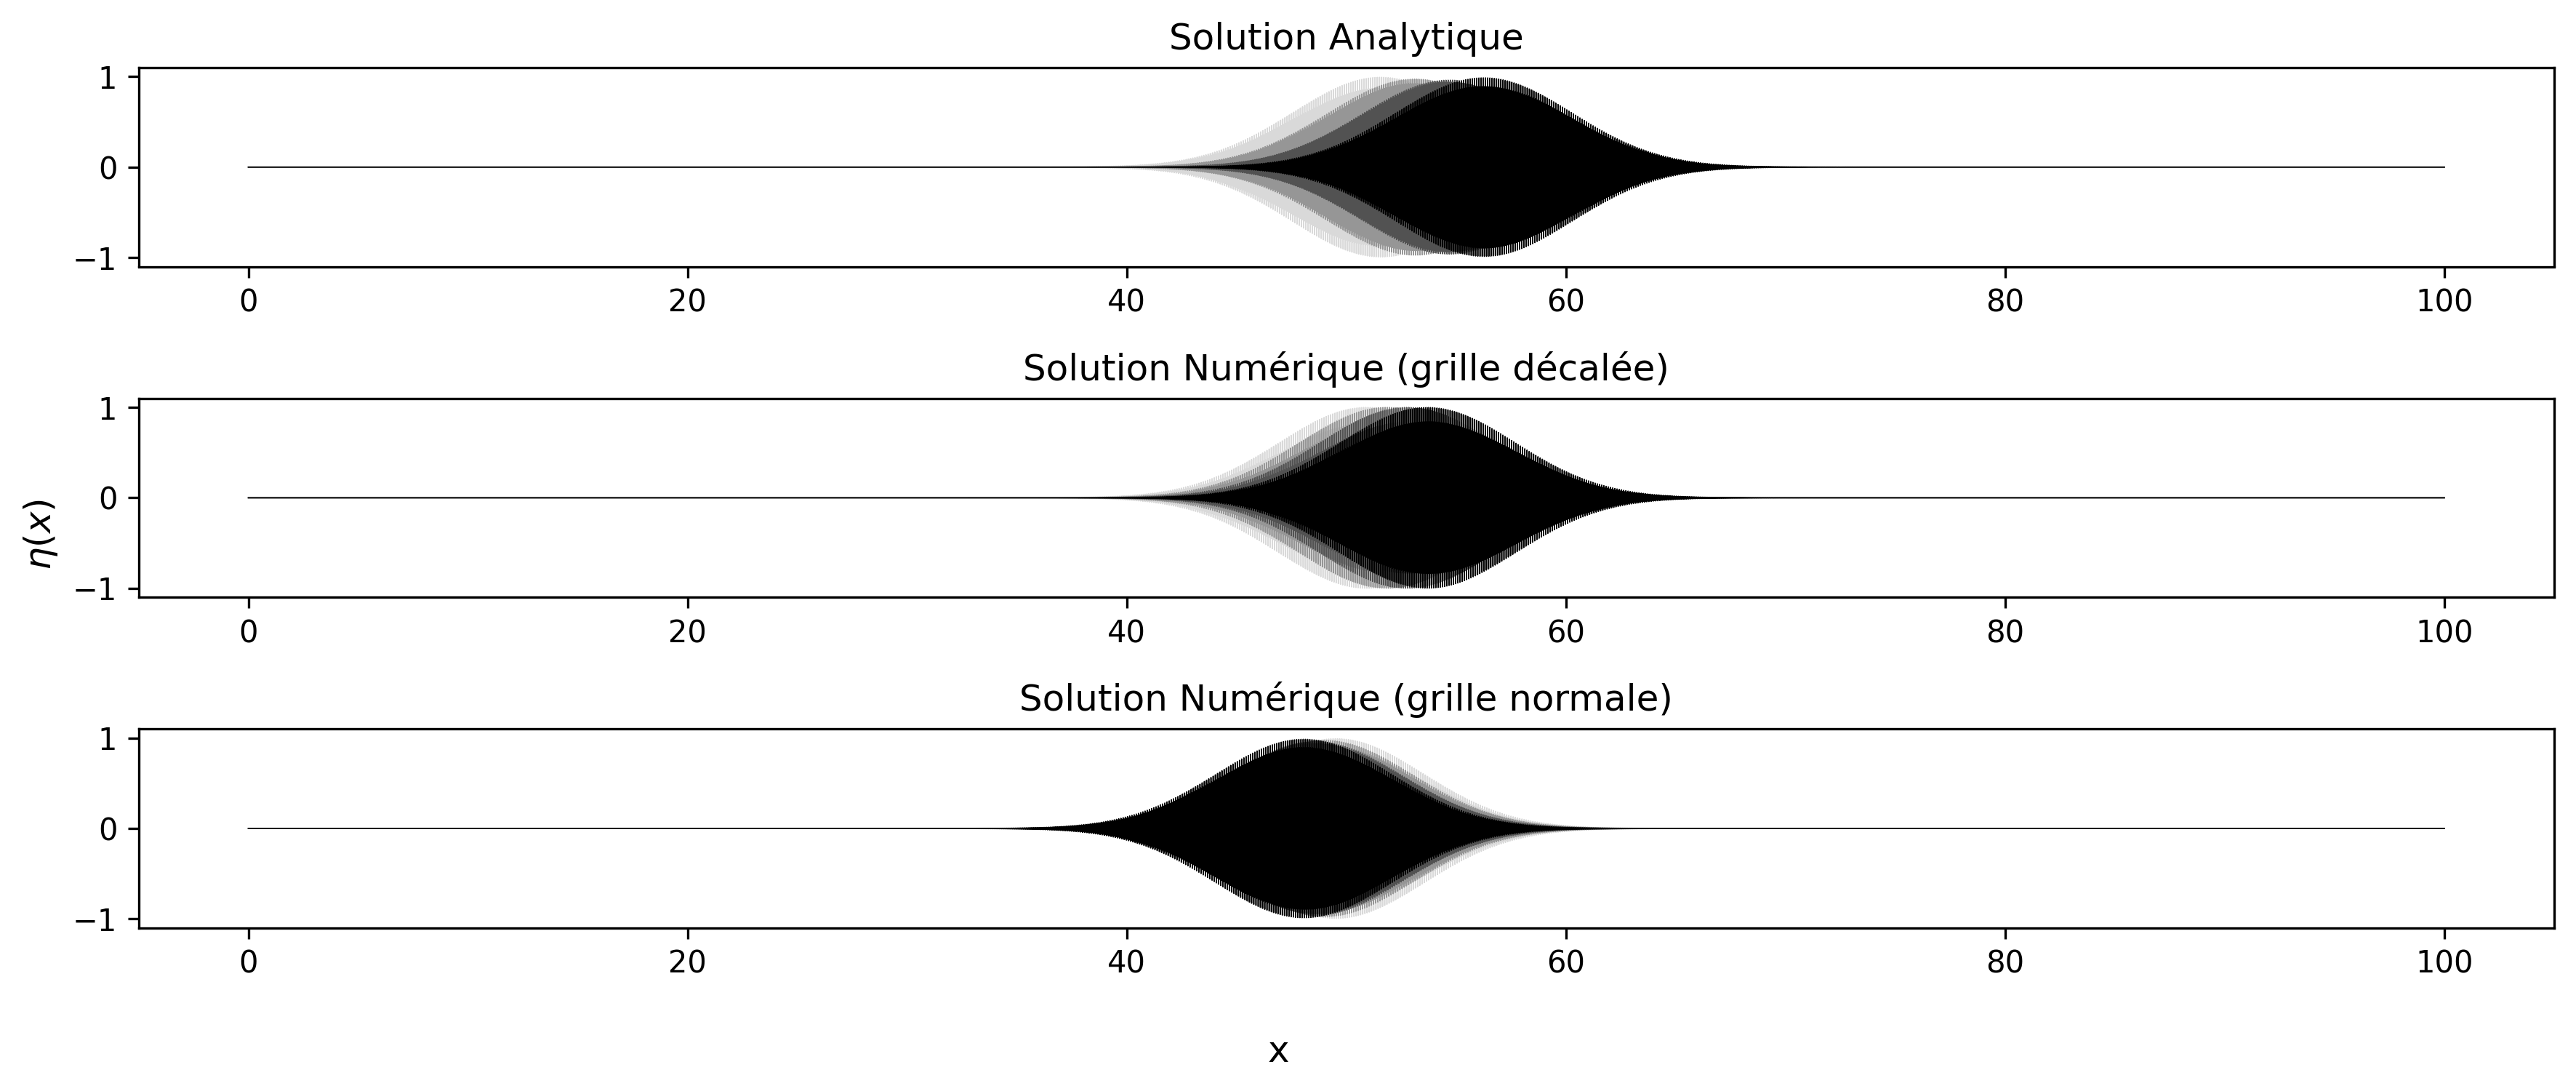

In [21]:
fig, ax = plt.subplots(3, 1, figsize=(12, 5), dpi = 300)

x_mesh,t_mesh = np.meshgrid(x_eta, t)
eta_ana = wave_packet(x_mesh, t_mesh, k0_factor * (np.pi/dx), sigma)
snapshot_time_indices = [0, int(0.25*len(t)), int(0.5*len(t)), int(0.75*len(t)), -1]
cmap = plt.get_cmap("Greys", len(snapshot_time_indices))
colors = [cmap(i) for i in range(len(snapshot_time_indices))]

for i, time_index in enumerate(snapshot_time_indices):

    ax[0].plot(x_eta, eta_ana[time_index], lw=0.4, color=colors[i])
    ax[0].set_title("Solution Analytique")
    ax[1].plot(x_eta, eta_stag[time_index], lw=0.4, color=colors[i])
    ax[1].set_title("Solution Numérique (grille décalée)")
 
    ax[2].plot(x_eta, eta[time_index], lw=0.4, color=colors[i])
    ax[2].set_title("Solution Numérique (grille normale)")
fig.supxlabel("x")
fig.supylabel("$\\eta(x)$")
plt.tight_layout()
plt.show()

**Question 15 :** Conclure sur l’avantage pratique de la grille décalée pour les simulations.

**Réponse 15 :** La grille décalée :
- a une constante d’erreur spatiale plus faible,
- permet une maille deux fois plus grande pour une précision équivalente,
- retrouve alors le même pas de temps maximal que la grille non décalée,
- reproduit mieux la propagation des ondes.
Elle est donc plus efficace pour les simulations d’ondes.